In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from scipy.stats import mannwhitneyu
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import sys
from tqdm import tqdm
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
from border_effects_kNN_del import trunc_graphs, get_mibitof, get_squidpy_visium_datasets

['BosporusFlow', 'ConstantFit', 'Delaunay', 'ExponentialSaturationFit', 'Fit', 'MichaelisMentenFit', 'NearestNeighbors', 'PiecewiseLinearFit', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'akaike_information_criterion', 'centrality_measures', 'combinations', 'compute_centrality_measures', 'curve_fit', 'delaunay_edges', 'distance_to_convex_hull', 'distance_to_mask', 'distance_to_pointset', 'distance_to_rectangular_border', 'distances', 'evaluate_fit', 'fit', 'graph_construction', 'knn_edges', 'log_likelihood', 'np', 'pd', 'pipeline', 'rnn_edges']


In [4]:
np.random.seed(41)

In [5]:
try:
    with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
        datasets = pickle.load(f)
except FileNotFoundError:
    datasets = get_mibitof().update(get_squidpy_visium_datasets())
    with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "wb") as f:
        pickle.dump(datasets, f)
            
try:
    all_results = pd.read_csv("/data/bionets/je30bery/truncated_graphs/results/trunc_effects/del_trunc.csv")
except:

    dfs = list()
    for square_limits in [(1/8, 7/8)]:
        df = pd.DataFrame(columns=["data_source", "node density in ROI", "% new edges", "P", "border_size"])
        for dataset in tqdm(datasets):
            coords = datasets[dataset]
            width = np.max(coords[:, 0]) - np.min(coords[:, 0])
            height = np.max(coords[:, 1]) - np.min(coords[:, 1])
            assert width > 0 and height > 0, f"problem, {width}, {height}"
                
            
            xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
            ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 
    
            try:
                out = trunc_graphs(coords=coords, return_graphs=False, method="delaunay", xlim=xlim, ylim=ylim)
                edge_df = out["edge_df"]
            
                old = edge_df.loc[~edge_df["New edge"], "Edge length"]
                new = edge_df.loc[edge_df["New edge"], "Edge length"]
            
                p_mwu = mannwhitneyu(
                    old,
                    new,
                    alternative="two-sided"
                ).pvalue
                data_source = dataset.split(":")[0]
                df.loc[dataset] = [data_source, out["#nodes in ROI"] / (float(height) * float(width)), len(new) / (len(new) + len(old)), p_mwu, square_limits[0]]
            except: # if too few cells are within ROI
                continue
        dfs.append(df)
    
    all_results = pd.concat(dfs)
    all_results["% new edges"] *= 100
    _, all_results["P_adj"], _, _ = multipletests(all_results["P"], alpha=0.05, method="fdr_bh")
    all_results.to_csv("/data/bionets/je30bery/truncated_graphs/results/trunc_effects/del_trunc.csv")

In [7]:
square_limits = (1/8, 7/8)
coords = datasets['glioma_mibitof:Brainiaqc_R1C1_whole_cell.tiff']
width = np.max(coords[:, 0]) - np.min(coords[:, 0])
height = np.max(coords[:, 1]) - np.min(coords[:, 1])

xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 

out = trunc_graphs(coords=coords, return_graphs=True, method="delaunay", xlim=xlim, ylim=ylim)

coords = out["coords"]
subset = out["subset"]

G = out["G"]
subG = out["subG"]
plotG = out["plotG"]
truncG = out["truncG"]

edge_df = out["edge_df"]

In [8]:
p = mannwhitneyu(
    edge_df.loc[~edge_df["New edge"], "Edge length"],
    edge_df.loc[edge_df["New edge"], "Edge length"],
    alternative="two-sided"
).pvalue

In [9]:
ori = edge_df["New edge"].value_counts()[False]
new = len(edge_df) - ori
print(len(truncG.nodes))
print(ori, new, p)

480
1352 68 2.421962074293223e-27


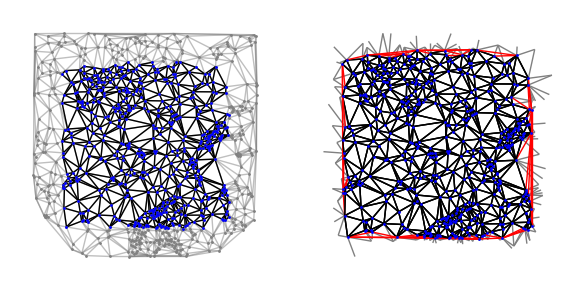

In [10]:
f, axs = plt.subplots(1, 2, figsize=(6, 3))

nx.draw(G, pos=coords, edge_color=(0.5, 0.5, 0.5, 0.5), node_size=1, node_color="gray", ax=axs[0])
nx.draw(subG, node_size=1, pos=coords, node_color="blue", ax=axs[0])

nx.draw_networkx_edges(plotG, pos=coords, ax=axs[1], edge_color="gray")
nx.draw(subG, node_size=1, pos=coords, ax=axs[1], node_color="blue")

edge_colors = [edge in G.edges for edge in truncG.edges]
nx.draw_networkx_edges(truncG, pos=coords, ax=axs[1], edge_color=np.where(edge_colors, "black", "red")) #, node_color=subcoords[:, 2], cmap="magma", vmin=-1, vmax=1)

for ax in axs:
    ax.set_aspect('equal')

plt.tight_layout()
#plt.savefig("../result_plots/fig2/delaunay_trunc_1.svg")

In [11]:
sources = sorted(list(all_results["data_source"].unique()))
palette = dict(zip(sources, sns.color_palette("magma", len(sources))))

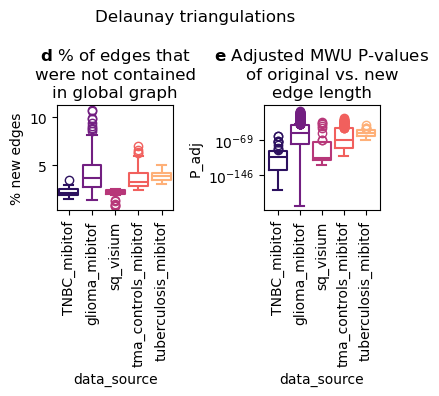

In [17]:
f, axs = plt.subplots(1, 2, figsize=(4, 4))

#sns.violinplot(edge_df, y="Edge length", hue="New edge", cut=0, fill=False, split=True, palette={False: "black", True: "red"}, ax=axs[0], hue_order=[True, False], inner=None)

sns.boxplot(all_results, x="data_source", y="% new edges", ax=axs[0], hue="data_source", legend=False, palette=palette, order=sources, fill=False)
sns.boxplot(all_results, x="data_source", y="P_adj", ax=axs[1], hue="data_source", legend=False, palette=palette, order=sources, fill=False)
axs[1].hlines(0.001, xmin=0, xmax=all_results["node density in ROI"].max(), color="gray")
axs[1].set_yscale("log")

f.suptitle("Delaunay triangulations")
axs[0].set_title("$\\mathbf{d}$ % of edges that\nwere not contained\nin global graph")
axs[1].set_title("$\\mathbf{e}$ Adjusted MWU P-values\nof original vs. new\nedge length")
axs[0].tick_params(axis='x', labelrotation=90)
axs[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.savefig("../result_plots/delaunay_trunc.pdf", bbox_inches="tight")

In [16]:
all_results

,Unnamed: 0,data_source,node density in ROI,% new edges,P,border_size,P_adj
0,glioma_mibitof:Brainiaqc_R1C1_whole_cell.tiff,glioma_mibitof,0.000115,4.788732,2.421962e-27,0.125,2.713953e-27
1,glioma_mibitof:Brainiaqc_R1C2_whole_cell.tiff,glioma_mibitof,0.001327,1.693791,8.205697e-173,0.125,2.669416e-171
2,glioma_mibitof:Brainiaqc_R1C3_whole_cell.tiff,glioma_mibitof,0.000983,2.014025,6.256501e-132,0.125,7.157162e-131
3,glioma_mibitof:Brainiaqc_R1C4_whole_cell.tiff,glioma_mibitof,0.000448,2.936437,2.860260e-75,0.125,8.293957e-75
4,glioma_mibitof:Brainiaqc_R2C1_whole_cell.tiff,glioma_mibitof,0.000084,5.700483,2.901838e-26,0.125,3.203408e-26
...,...,...,...,...,...,...,...
1036,sq_visium:Visium_FFPE_Human_Breast_Cancer,sq_visium,0.000007,2.426825,6.824080e-86,0.125,2.680705e-85
1037,sq_visium:Visium_FFPE_Human_Prostate_Acinar_Ce...,sq_visium,0.000007,1.875293,4.291666e-79,0.125,1.357941e-78
1038,sq_visium:Visium_FFPE_Human_Prostate_Cancer,sq_visium,0.000007,2.146084,1.842643e-111,0.125,1.410435e-110
1039,sq_visium:Visium_FFPE_Human_Prostate_IF,sq_visium,0.000007,2.468374,1.998918e-109,0.125,1.465404e-108
